# Non-deep LDA: mu dynamics comparison

This notebook compares three dynamics for a 1D two-class Gaussian LDA model with class means constrained to $\pm\mu$ and fixed variance $1$:

1. finite-sample gradient ascent,
2. population-level gradient ascent,
3. population-level gradient flow.

All three trajectories are plotted on the same figure.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 17
plt.rcParams["axes.titlesize"] = 19
plt.rcParams["axes.labelsize"] = 18
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 15


In [2]:
# Experiment setup
rng = np.random.default_rng(7)

N = 200                  # finite sample size per run
n_runs = 200             # number of finite-sample runs
m_true = 1.0             # true class-separation parameter in x = y*m_true + eps
mu0 = 0.0                # initialization for trainable mu
alpha = 0.1                # gradient ascent step size
steps = 80               # number of discrete updates
ci_z = 1.96              # 95% normal-approx confidence multiplier

print(f"true E[yx] = {m_true:.4f}")
print(f"finite-sample runs = {n_runs}, sample size per run = {N}")


true E[yx] = 1.0000
finite-sample runs = 200, sample size per run = 200


In [3]:
def run_gradient_ascent(mu_init: float, target: float, lr: float, num_steps: int) -> np.ndarray:
    """Discrete gradient ascent for dmu = target - mu."""
    mu_hist = np.empty(num_steps + 1)
    mu_hist[0] = mu_init
    mu = mu_init
    for k in range(num_steps):
        grad = target - mu
        mu = mu + lr * grad
        mu_hist[k + 1] = mu
    return mu_hist


# (a) finite-sample gradient ascent over many independent datasets
m_hats = np.empty(n_runs)
mu_finite_ga_runs = np.empty((n_runs, steps + 1))

for r in range(n_runs):
    y = rng.choice(np.array([-1.0, 1.0]), size=N)
    x = y * m_true + rng.standard_normal(size=N)
    m_hat_r = np.mean(y * x)

    m_hats[r] = m_hat_r
    mu_finite_ga_runs[r] = run_gradient_ascent(mu0, m_hat_r, alpha, steps)

mu_finite_ga_mean = mu_finite_ga_runs.mean(axis=0)
mu_finite_ga_std = mu_finite_ga_runs.std(axis=0, ddof=1)
mu_finite_ga_se = mu_finite_ga_std / np.sqrt(n_runs)
mu_finite_ga_ci_lo = mu_finite_ga_mean - ci_z * mu_finite_ga_se
mu_finite_ga_ci_hi = mu_finite_ga_mean + ci_z * mu_finite_ga_se

# (b) population gradient ascent: target = m_true
mu_population_ga = run_gradient_ascent(mu0, m_true, alpha, steps)

# (c) population gradient flow: dmu/dt = m_true - mu
t_grid = np.linspace(0.0, alpha * steps, steps + 1)
mu_population_gf = m_true + (mu0 - m_true) * np.exp(-t_grid)

print(f"mean finite-sample E[yx] estimate = {m_hats.mean():.4f}")
print(f"std finite-sample E[yx] estimate = {m_hats.std(ddof=1):.4f}")


mean finite-sample E[yx] estimate = 0.9975
std finite-sample E[yx] estimate = 0.0707


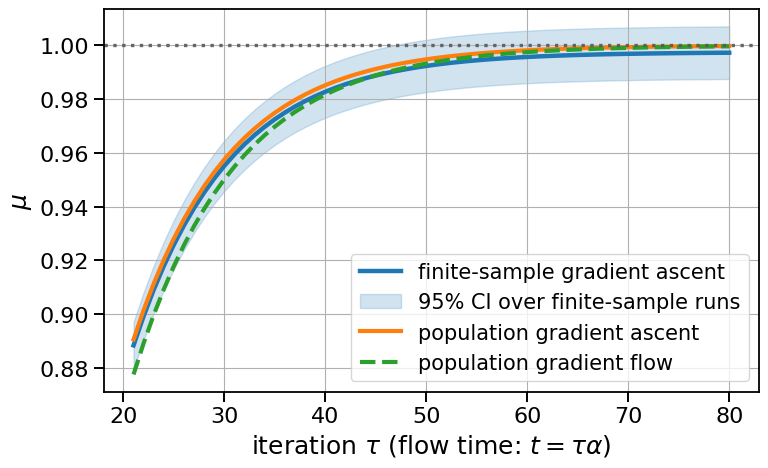

In [6]:
k_grid = np.arange(steps + 1)
last_k = 60
idx = slice(-last_k, None)

fig, ax = plt.subplots()

# Finite-sample mean and confidence band
ax.plot(
    k_grid[idx],
    mu_finite_ga_mean[idx],
    lw=3.2,
    color="C0",
    label="finite-sample gradient ascent",
)
ax.fill_between(
    k_grid[idx],
    mu_finite_ga_ci_lo[idx],
    mu_finite_ga_ci_hi[idx],
    color="C0",
    alpha=0.20,
    label="95% CI over finite-sample runs",
)

# Population curves
ax.plot(k_grid[idx], mu_population_ga[idx], lw=3.0, color="C1", label="population gradient ascent")
ax.plot(k_grid[idx], mu_population_gf[idx], "--", lw=3.0, color="C2", label="population gradient flow")

ax.axhline(m_true, color="0.35", ls=":", lw=2.4, alpha=0.9)

# Publication-style tick and frame settings
ax.tick_params(axis="both", which="major", direction="out", length=7, width=1.4)
ax.tick_params(axis="both", which="minor", direction="out", length=4, width=1.1)
for spine in ax.spines.values():
    spine.set_linewidth(1.3)

ax.set_xlabel(r"iteration $\tau$ (flow time: $t = \tau\alpha$)")
ax.set_ylabel(r"$\mu$")
ax.legend(loc="best", frameon=True)
fig.tight_layout()

plt.savefig('mu_dynamics.png', dpi=600)
